# Learned Predictions for Shortest Path — Advanced A*
**Progetto finale — Advanced Topics in Algorithms**
Nicole Mietto, Davide Sut

Questo notebook orchestra l'intera pipeline di Machine Learning per l'ottimizzazione del routing stradale.
Tutta la logica matematica, di addestramento e di valutazione è modularizzata nei pacchetti `src/`, `modelli/` e `valutazione/`.


## 0. Setup Ambiente e Motore C++


In [19]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/NicoleMietto/padova-routing.git"  # <-- aggiorna
    REPO_DIR = "/content/padova-routing"
    if not os.path.exists(REPO_DIR):
        os.system(f"git clone {REPO_URL} {REPO_DIR}")
    sys.path.insert(0, REPO_DIR)
    os.system(f"pip install -q -r {REPO_DIR}/requirements.txt")
else:
    sys.path.insert(0, ".")

print(f"Ambiente: {'Colab' if IN_COLAB else 'locale'}")


Ambiente: Colab


In [20]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Unipd/test_totale" if IN_COLAB else "dati_test"

GRAFI_DIR = os.path.join(PROJECT_DIR, "grafi") if IN_COLAB else PROJECT_DIR
MODELLI_DIR = os.path.join(PROJECT_DIR, "modelli_salvati") if IN_COLAB else os.path.join(PROJECT_DIR, "modelli_salvati")
TRAFFICO_DIR = os.path.join(PROJECT_DIR, "traffico")
GRAFICI_DIR = os.path.join(PROJECT_DIR, "grafici e immagini")

for d in [GRAFI_DIR, MODELLI_DIR, TRAFFICO_DIR, GRAFICI_DIR]:
    os.makedirs(d, exist_ok=True)

GRAPHML_PATH = os.path.join(GRAFI_DIR, "padova_drive.graphml")
GRAPHML_VENETO_PATH = os.path.join(GRAFI_DIR, "veneto_drive.graphml")

MODEL_PATH_CASUALE = os.path.join(MODELLI_DIR, "modello_bcf_casuale.json")
MODEL_PATH_3ANELLI = os.path.join(MODELLI_DIR, "modello_bcf_3anelli.json")
MODEL_PATH_3ANELLI_CONS = os.path.join(MODELLI_DIR, "modello_bcf_3anelli_cons.json")
MODEL_PATH_6ANELLI = os.path.join(MODELLI_DIR, "modello_bcf_6anelli.json")
MODEL_PATH_TRAFFICO = os.path.join(MODELLI_DIR, "modello_bcf_traffico.json")
MODEL_PATH_VENETO = os.path.join(MODELLI_DIR, "modello_bcf_veneto.json")

BCF_INPUT_PATH = "/content/padova_bcf_input.txt" if IN_COLAB else "padova_bcf_input.txt"
BCF_DIR = "/content/negative_weight_SSSP" if IN_COLAB else "negative_weight_SSSP"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from src.bcf import compila_bcf
BCF_BIN = compila_bcf(BCF_DIR)


✅ Già compilato: /content/negative_weight_SSSP/build/Main


In [22]:
from src.grafo import carica_ambiente
print("Caricamento del grafo di Padova...")
G_padova, _ = carica_ambiente(GRAPHML_PATH)

Caricamento del grafo di Padova...
Grafo caricato: 43387 nodi, 95645 archi


### Caricamento Modelli Pre-addestrati
Se i modelli sono già stati salvati su Drive (es. da una sessione precedente), li carichiamo subito in RAM per non dover ripetere il training. Le celle di addestramento sottostanti potranno essere saltate.


In [23]:
import xgboost as xgb
from modelli.pipeline_unificata import WrapperXGBoost
cols_base = ["node_lat", "node_lon", "target_lat", "target_lon", "haversine_dist_m"]
cols_traffico = cols_base + ["periodo_giorno"]

def carica_se_esiste(path, cols):
    if os.path.exists(path):
        b = xgb.Booster()
        b.load_model(path)
        return WrapperXGBoost(b, cols)
    return None
model_casuale = carica_se_esiste(MODEL_PATH_CASUALE, cols_base)
model_3anelli = carica_se_esiste(MODEL_PATH_3ANELLI, cols_base)
# FIX: model_3anelli_cons (training con loss custom, usato in Tappa 2/3/Finale)
# mancava in questa lista — senza questa riga, ricaricando da Drive in una
# nuova sessione (senza rieseguire la cella 15), model_3anelli_cons resterebbe
# indefinito e le celle 21/24 darebbero NameError.
model_3anelli_cons = carica_se_esiste(MODEL_PATH_3ANELLI_CONS, cols_base)
model_6anelli = carica_se_esiste(MODEL_PATH_6ANELLI, cols_base)
model_traffico = carica_se_esiste(MODEL_PATH_TRAFFICO, cols_traffico)
model_veneto = carica_se_esiste(MODEL_PATH_VENETO, cols_base)
modelli_caricati = sum(
    1 for m in [model_casuale, model_3anelli, model_3anelli_cons, model_6anelli, model_traffico, model_veneto]
    if m is not None
)

print(f"Trovati e caricati in RAM {modelli_caricati} modelli pre-addestrati da Drive.")

Trovati e caricati in RAM 2 modelli pre-addestrati da Drive.


## 1. Il Laboratorio: Viaggio Verso il Miglior Modello
In questa fase affrontiamo un rigoroso **Ablation Study**. Introdurremo un miglioramento architetturale alla volta per dimostrare matematicamente *perché* il nostro modello finale funziona.


In [24]:
import xgboost as xgb
from modelli.pipeline_unificata import WrapperXGBoost, genera_dataset_unificato, allena_modello_unificato
from src.grafo import classifica_per_fasce
from valutazione.benchmark_nodi_esplorati import genera_coppie_per_tipologia, confronta_nodi_esplorati
from valutazione.confronto_modelli import confronta_modelli_runtime, plot_confronto_modelli_boxplot
CENTRO_PADOVA = {"Padova": (45.4064, 11.8768)}
FASCE_CASUALE = [(0, 60)]
FASCE_3_ANELLI = [(0, 5), (5, 15), (15, 60)]
FASCE_6_ANELLI = [(0, 1), (1, 3), (3, 6), (6, 12), (12, 25), (25, 60)]
FASCE_VENETO = [(0, 5), (5, 15), (15, 60), (60, 150)]
# =================================================================================================
# ATTENZIONE: Questo NON è il dataset di addestramento!
# Stiamo generando un "Set di Test" indipendente basato sulla TIPOLOGIA TOPOLOGICA della rotta.
# Vogliamo distinguere rotte puramente urbane (il collo di bottiglia) da rotte extraurbane.
# =================================================================================================
nodi_per_fascia_test = classifica_per_fasce(G_padova, CENTRO_PADOVA["Padova"][0], CENTRO_PADOVA["Padova"][1], FASCE_3_ANELLI)
coppie_test_stratificate = genera_coppie_per_tipologia(
    nodi_per_fascia_test, n_coppie_per_tipo=30
)

### 1.1 L'Importanza della Geografia Urbana (Gli Anelli)
Il modello globale (Casuale) assume una velocità media per tutta Padova. Questo significa che sottostima pesantemente i tempi nel lento Centro Storico (collo di bottiglia computazionale).
Stratificando il dataset di training in 3 Anelli, obblighiamo la rete neurale a studiare e dare lo stesso peso al complesso Centro cittadino.
*Nota bene*: In questa prima tappa addestreremo i modelli usando SOLO l'Errore Quadratico Medio (MSE). Questo ci permetterà di isolare e dimostrare visivamente i due problemi principali: la bassa precisione geografica e le violazioni matematiche (outlier).

In [25]:
print("Generazione dataset Casuale (Baseline globale)...")
df_train_casuale, G_dict_casuale = genera_dataset_unificato(
    G_padova, CENTRO_PADOVA, FASCE_CASUALE, target_per_fascia=60, sorgenti_per_fascia_per_target=300
)

print("Addestramento Modello Casuale (Solo MSE)...")
booster_casuale, cols_casuale, _ = allena_modello_unificato(G_dict_casuale, df_train_casuale, lambda_consistenza=0.0, n_round=150)
model_casuale = WrapperXGBoost(booster_casuale, cols_casuale)

print("\\nGenerazione dataset 3 Anelli...")
df_train_3, G_dict_3 = genera_dataset_unificato(
    G_padova, CENTRO_PADOVA, FASCE_3_ANELLI, target_per_fascia=20, sorgenti_per_fascia_per_target=100
)

print("Addestramento Modello 3 Anelli (Solo MSE)...")
booster_3anelli_mse, cols_3, _ = allena_modello_unificato(G_dict_3, df_train_3, lambda_consistenza=0.0, n_round=150)
model_3anelli_mse = WrapperXGBoost(booster_3anelli_mse, cols_3)

Generazione dataset Casuale (Baseline globale)...

[Traffico=OFF] Uso del grafo standard...

=== Elaborazione Centro: Padova ===
  30/60 target completati.
  60/60 target completati.

Generazione completata: 18000 righe totali da 1 centri.
Addestramento Modello Casuale (Solo MSE)...
Recupero vicini per calcolo consistenza topologica...

Training XGBoost con loss custom (lambda=0.0)...
  Round 1/150  (0.3s trascorsi)
  Round 50/150  (3.2s trascorsi)
  Round 100/150  (5.0s trascorsi)
  Round 150/150  (8.3s trascorsi)

=== Valutazione modello ===
  MAE  train: 43.5s   |  MAE  test: 60.6s
  R²   train: 0.995     |  R²   test: 0.989
\nGenerazione dataset 3 Anelli...

[Traffico=OFF] Uso del grafo standard...

=== Elaborazione Centro: Padova ===
  30/60 target completati.
  60/60 target completati.

Generazione completata: 18000 righe totali da 1 centri.
Addestramento Modello 3 Anelli (Solo MSE)...
Recupero vicini per calcolo consistenza topologica...

Training XGBoost con loss custom (lambda

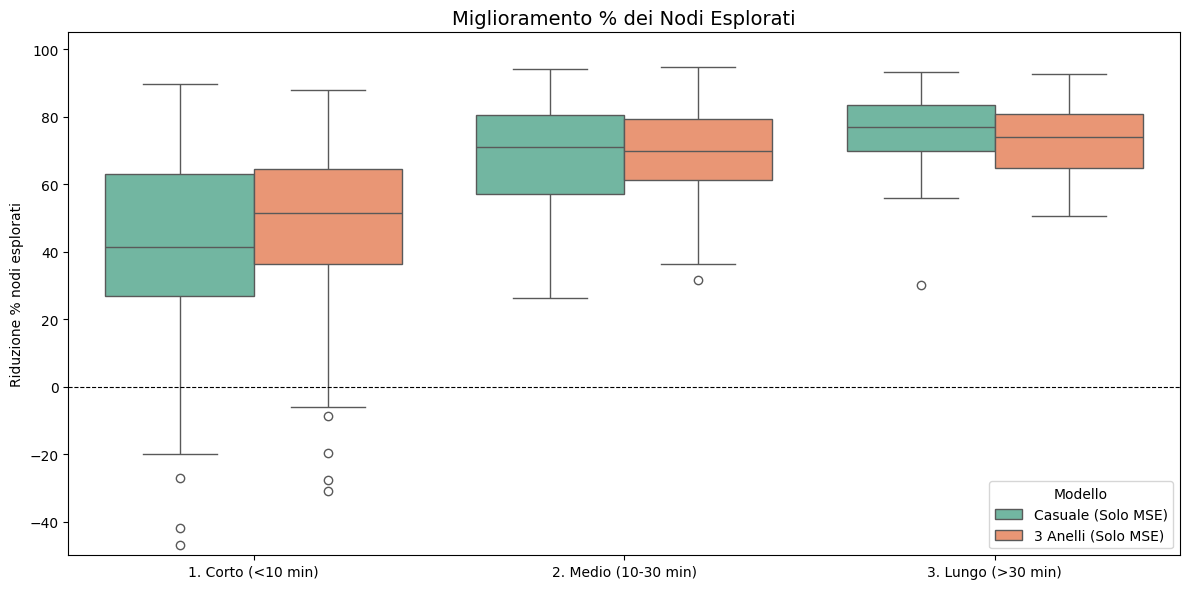

In [24]:
# Confronto Tappa 1 (Effetto Geografia)
df_risultati_tappa1 = confronta_modelli_runtime(
    G_padova,
    {"Casuale (Solo MSE)": model_casuale, "3 Anelli (Solo MSE)": model_3anelli_mse},
    coppie_test_stratificate, BCF_BIN, BCF_INPUT_PATH
)
# Usiamo un y_limit per non far schiacciare troppo i box dagli outlier infernali che ci aspettiamo
plot_confronto_modelli_boxplot(df_risultati_tappa1, os.path.join(GRAFICI_DIR, "tappa1_geografia.png"), y_limit=(-50, 105))

### 1.2 L'Importanza della Matematica (La Loss di Consistenza)
Il grafico precedente dimostra che il modello a 3 Anelli migliora la Mediana sulle "Tratte Urbane" (capisce la geografia).
TUTTAVIA, entrambi i modelli producono degli spaventosi outlier in negativo. Perché? Perché una rete addestrata solo sull'MSE viola regolarmente la disuguaglianza triangolare (crea "buche" nel grafo), mandando l'algoritmo A* in panico.

Dimostriamo ora cosa succede prendendo il nostro modello intelligente (3 Anelli) e forzandolo a rispettare le regole matematiche di A* usando una **Loss Custom di Consistenza Topologica** (`lambda=0.5`).


Tuttavia, la nostra Loss di Consistenza velocizza l'algoritmo enormemente per due motivi (uno teorico e uno pratico):

Riduce
W
m
a
x
W
max
​
  (Vantaggio Teorico): La nostra Loss non si limita a "cancellare" gli archi negativi, ma penalizza matematicamente la violazione della disuguaglianza triangolare. Questo significa che i pochi archi negativi che "sopravvivono" alla rete neurale avranno un valore assoluto bassissimo (es. -2 invece di -500). Abbattendo il peso assoluto massimo, crolla il numero di fasi di scaling (
log
⁡
(
W
)
log(W) diventa piccolissimo).
Riduce il sottografo negativo (Vantaggio Pratico): Anche se il numero di fasi di scaling fosse lo stesso, all'interno di ogni singola fase l'algoritmo di Rinaldi/Bernstein deve fare operazioni complesse (come Decomposizioni a Basso Diametro o Fix-Up di componenti fortemente connesse) sugli archi violati. Meno archi negativi ci sono nel grafo, più queste strutture dati interne si svuotano, e l'algoritmo salta i calcoli.
In sintesi da dire all'esame: "La Loss di Consistenza è vitale per l'algoritmo di Rinaldi/Bernstein perché agisce su due fronti: riduce il numero di archi negativi (alleggerendo il lavoro pratico delle strutture dati interne) e, soprattutto, schiaccia verso lo zero il valore assoluto massimo del peso negativo (abbattendo il numero di fasi di scaling logaritmico richieste dalla teoria)."

In [26]:
print("Addestramento Modello 3 Anelli (A* Consistente, lambda=0.5)...")
booster_3anelli_cons, cols_3_cons, _ = allena_modello_unificato(G_dict_3, df_train_3, lambda_consistenza=0.5, n_round=150)
booster_3anelli_cons.save_model(MODEL_PATH_3ANELLI_CONS)
model_3anelli_cons = WrapperXGBoost(booster_3anelli_cons, cols_3_cons)


Addestramento Modello 3 Anelli (A* Consistente, lambda=0.5)...
Recupero vicini per calcolo consistenza topologica...

Training XGBoost con loss custom (lambda=0.5)...
  Round 1/150  (0.0s trascorsi)
  Round 50/150  (1.0s trascorsi)
  Round 100/150  (2.9s trascorsi)
  Round 150/150  (5.8s trascorsi)

=== Valutazione modello ===
  MAE  train: 42.8s   |  MAE  test: 58.5s
  R²   train: 0.995     |  R²   test: 0.990


Calcolo baseline Dijkstra su 90 coppie...

=== Modello: 3 Anelli (Solo MSE) ===

=== Modello: 3 Anelli (Consistenza) ===



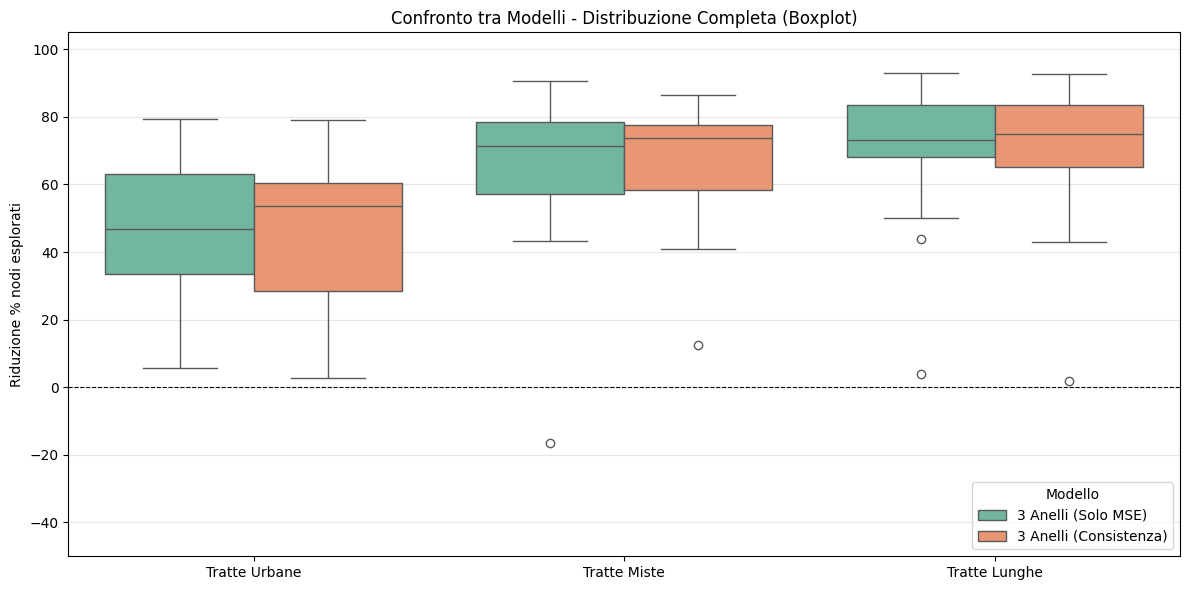

Boxplot salvato come '/content/drive/MyDrive/Unipd/test_totale/grafici e immagini/tappa2_consistenza.png'


In [27]:
# Confronto Tappa 2 (Effetto Matematica)
df_risultati_tappa2 = confronta_modelli_runtime(
    G_padova,
    {"3 Anelli (Solo MSE)": model_3anelli_mse, "3 Anelli (Consistenza)": model_3anelli_cons},
    coppie_test_stratificate, BCF_BIN, BCF_INPUT_PATH
)
plot_confronto_modelli_boxplot(df_risultati_tappa2, os.path.join(GRAFICI_DIR, "tappa2_consistenza.png"), y_limit=(-50, 105))

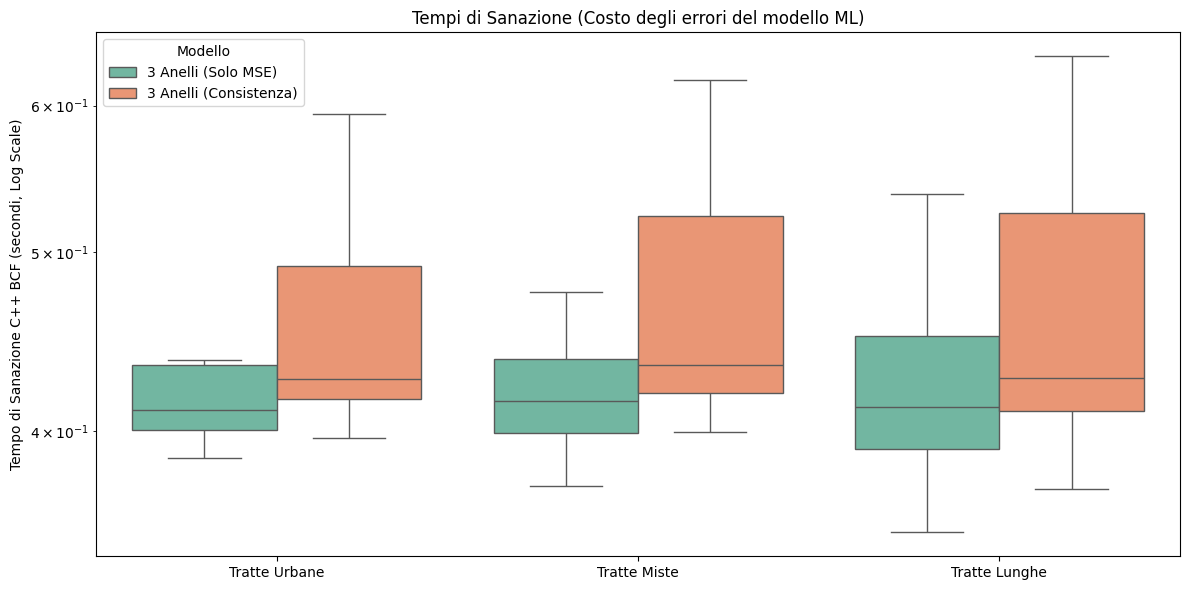

Grafico salvato come '/content/drive/MyDrive/Unipd/test_totale/grafici e immagini/tappa2_runtime_bcf.png'


In [28]:
from valutazione.confronto_modelli import plot_confronto_modelli_tempo_bcf
import os
# Usiamo la funzione apposita per estrarre la colonna 'tempo_bcf_s' (il Runtime!)
plot_confronto_modelli_tempo_bcf(
    df_risultati_tappa2,
    os.path.join(GRAFICI_DIR, "tappa2_runtime_bcf.png")
)

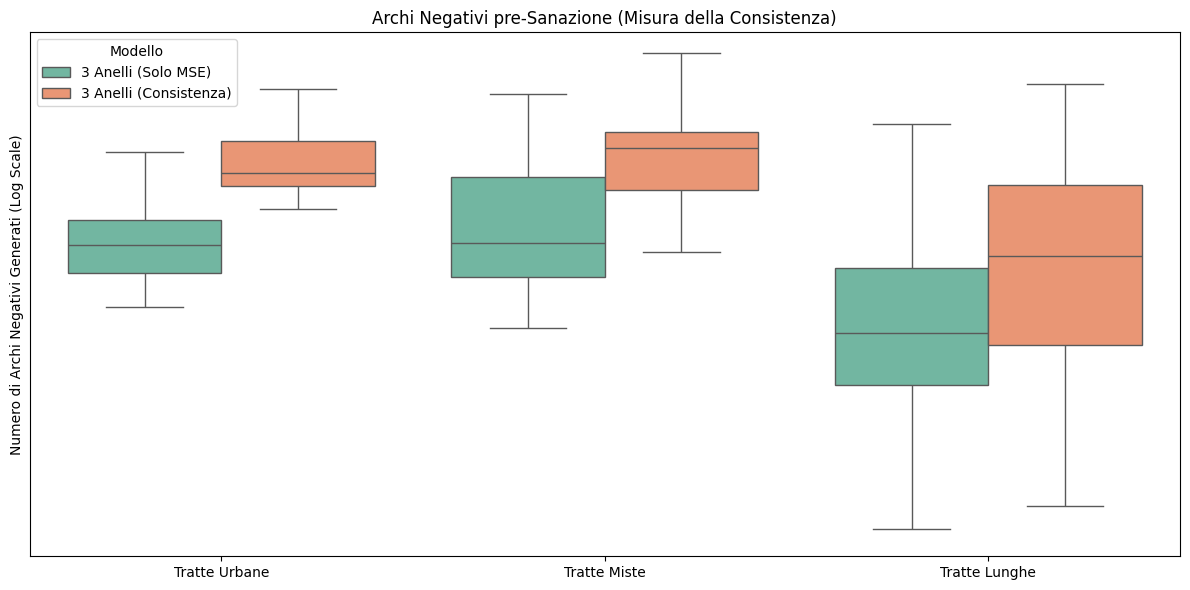

Grafico salvato come '/content/drive/MyDrive/Unipd/test_totale/grafici e immagini/tappa2_archi_negativi.png'


In [29]:
from valutazione.confronto_modelli import plot_confronto_modelli_archi_negativi
import os

# Usiamo la funzione già presente nel vostro codice per disegnare gli archi negativi
plot_confronto_modelli_archi_negativi(
    df_risultati_tappa2,
    os.path.join(GRAFICI_DIR, "tappa2_archi_negativi.png")
)

### 1.3 La Granularità (Rasoio di Ockham): 3 Anelli vs 6 Anelli
Abbiamo dimostrato il potere del Campionamento Stratificato geografico. Aumentare vertiginosamente il numero di anelli (passando da 3 a 6) porta ulteriori benefici, o ci fa ricadere nell'overfitting rendendo il modello meno generalizzabile?


In [ ]:
print("Generazione dataset 6 Anelli...")
df_train_6, G_dict_6 = genera_dataset_unificato(
    G_padova, CENTRO_PADOVA, FASCE_6_ANELLI, target_per_fascia=10, sorgenti_per_fascia_per_target=50
)

print("Addestramento Modello 6 Anelli (A* Consistente, lambda=0.5)...")
booster_6anelli, cols_6, _ = allena_modello_unificato(G_dict_6, df_train_6, lambda_consistenza=0.5, n_round=150)
booster_6anelli.save_model(MODEL_PATH_6ANELLI)
model_6anelli = WrapperXGBoost(booster_6anelli, cols_6)


In [ ]:
# Confronto Tappa 3
# FIX: era "model_3anelli" (il modello caricato in cella 7, eventualmente
# allenato solo con MSE in una sessione precedente) invece di
# "model_3anelli_cons" (il modello con loss custom allenato in cella 15,
# quello effettivamente confrontato nelle Tappe 2/3). Con il nome sbagliato
# il confronto non isolava più l'effetto della granularita' (3 vs 6 anelli),
# perche' mischiava anche l'effetto della loss custom.
df_risultati_tappa3 = confronta_modelli_runtime(
    G_padova,
    {"3 Anelli (Consistenza)": model_3anelli_cons, "6 Anelli (Consistenza)": model_6anelli},
    coppie_test_stratificate, BCF_BIN, BCF_INPUT_PATH
)
plot_confronto_modelli_boxplot(df_risultati_tappa3, os.path.join(GRAFICI_DIR, "tappa3_granularita.png"))


## 2. L'Intuizione Visiva (Test sulle Coppie Fisse)
Mostriamo i risultati del Modello Vincitore su alcune tratte note di Padova per avere un'idea visiva del risparmio di tempo e nodi esplorati.


In [ ]:
import requests, time
import osmnx as ox
import numpy as np

def coord_da_osm_id(osm_id: int) -> tuple[float, float]:
    url = f"https://www.openstreetmap.org/api/0.6/node/{osm_id}.json"
    r = requests.get(url, headers={"User-Agent": "padova-routing-project"})
    data = r.json()
    return data["elements"][0]["lat"], data["elements"][0]["lon"]

def nearest_node_raggiungibile(G, lat, lon):
    nodes_df = ox.graph_to_gdfs(G, edges=False)
    dlat, dlon = nodes_df["y"] - lat, nodes_df["x"] - lon
    nodes_df["dist"] = np.sqrt(dlat**2 + dlon**2)
    for nodo in nodes_df.sort_values("dist").index:
        if G.out_degree(nodo) > 1: return nodo
    return nodes_df.index[0]

NODI_FISSI = {"Stazione FS": 5752101509, "Ospedale Civile": 7324269676, "Duomo": 605047784, "Aeroporto": 567948984}
PERCORSI = [("Stazione FS", "Ospedale Civile"), ("Duomo", "Aeroporto")]

coppie_fisse = []
for n_src, n_dst in PERCORSI:
    lat_s, lon_s = coord_da_osm_id(NODI_FISSI[n_src]); time.sleep(0.5)
    lat_d, lon_d = coord_da_osm_id(NODI_FISSI[n_dst]); time.sleep(0.5)
    src = nearest_node_raggiungibile(G_padova, lat_s, lon_s)
    dst = nearest_node_raggiungibile(G_padova, lat_d, lon_d)
    coppie_fisse.append((f"{n_src} -> {n_dst}", src, dst, "Fisse"))

print("Coppie fisse caricate.")


In [ ]:
from valutazione.confronto_modelli import plot_confronto_modelli_singole_coppie

# Modifica model_vincitore in base ai risultati della Tappa 3 (probabilmente model_3anelli)
model_vincitore = model_3anelli

df_fisse_tidy = confronta_modelli_runtime(G_padova, {"Vincitore Padova": model_vincitore}, coppie_fisse, BCF_BIN, BCF_INPUT_PATH)
plot_confronto_modelli_singole_coppie(df_fisse_tidy, os.path.join(GRAFICI_DIR, "confronto_fisse.png"))


## 3. Il Mondo Reale: Robustezza al Traffico
Generiamo un grafo con traffico sintetico (penalizzazione oraria e radiale per il centro) e ri-addestriamo il modello su di esso per confermare che l'intelligenza di A* resiste ai cambiamenti dinamici.


In [ ]:
# FIX: il blocco "G_traffico = genera_traffico_realistico(...)" che era qui
# calcolava un grafo con traffico MAI USATO (codice morto): la riga sotto
# chiama genera_dataset_unificato(..., usa_traffico=True), che genera
# internamente i SUOI propri 3 grafi (Mattina/Pomeriggio/Sera) — quelli sono
# i grafi realmente usati per il training, non G_traffico. Il seed per quei
# grafi e' ora passato direttamente a genera_dataset_unificato (propagato
# internamente a genera_traffico_realistico, vedi fix in pipeline_unificata.py),
# quindi non serve piu' generare un grafo traffico separato qui.
print("Generazione dataset Traffico (3 Anelli)...")
df_train_traffico, G_dict_traffico = genera_dataset_unificato(
    G_padova, CENTRO_PADOVA, FASCE_3_ANELLI,
    target_per_fascia=10, sorgenti_per_fascia_per_target=50,
    usa_traffico=True, seed=42
)

print("Addestramento Modello Traffico...")
booster_traffico, cols_traff, _ = allena_modello_unificato(
    G_dict_traffico, df_train_traffico, lambda_consistenza=0.5, n_round=150
)
booster_traffico.save_model(MODEL_PATH_TRAFFICO)
model_traffico = WrapperXGBoost(booster_traffico, cols_traff)

## 4. Tecniche di Accelerazione: Sub-Graph e Interpolazione
Calcolare l'inferenza XGBoost su tutti i nodi del grafo ad ogni query richiede tempo computazionale.
L'estrazione dell'Ellisse e l'Interpolazione Delaunay permettono di riportare il tempo *wall-clock* al livello di Dijkstra Vanilla.


In [ ]:
from src.subgraph import extract_subgraph_ellipse, assicura_connessione
from src.interpolazione import genera_predizioni_interpolate

_nome, _src, _dst, _ = coppie_fisse[0]

G_ellisse = extract_subgraph_ellipse(G_padova, _src, _dst, padding_km=2.0)
G_ellisse = assicura_connessione(G_ellisse, G_padova, _src, _dst)
print(f"Nodi originali Padova: {len(G_padova.nodes())} -> Nodi nell'Ellisse: {len(G_ellisse.nodes())}")

# y_hat_interp, y_hat_int_interp = genera_predizioni_interpolate(
#    G_ellisse, model_3anelli, _dst, sample_ratio=0.1, seed=42
# )


## 5. Il Gran Finale: Scalabilità e Generalizzazione sul Veneto
Applichiamo l'A* Consistente al "mostro" regionale (240.000 nodi) passando da un sistema Mono-Centrico a uno **Multi-Centrico** che estrae le distanze da 7 capoluoghi di provincia contemporaneamente.


In [ ]:
# G_veneto, _ = carica_ambiente(GRAPHML_VENETO_PATH)
# print(f"Grafo Veneto caricato: {len(G_veneto.nodes())} nodi.")

CENTRI_VENETO = {
    "Padova": (45.4064, 11.8768),
    "Venezia": (45.4408, 12.3155),
    "Verona": (45.4384, 10.9916),
    "Treviso": (45.6669, 12.2461),
    "Vicenza": (45.5455, 11.5354),
    "Belluno": (46.1425, 12.2166),
    "Rovigo": (45.0712, 11.7885)
}

# print("Generazione dataset Multicentrico Veneto (richiede tempo)...")
# df_train_veneto, G_dict_veneto = genera_dataset_unificato(
#     G_veneto, CENTRI_VENETO, FASCE_VENETO, target_per_fascia=5, sorgenti_per_fascia_per_target=20
# )
#
# print("Addestramento Modello Veneto Multicentrico...")
# booster_veneto, cols_veneto, _ = allena_modello_unificato(
#     G_dict_veneto, df_train_veneto, lambda_consistenza=0.5, n_round=200
# )
# booster_veneto.save_model(MODEL_PATH_VENETO)
# model_veneto = WrapperXGBoost(booster_veneto, cols_veneto)
